# Classification - Road Traffic Accident Severity

## 23CSE301 Machine Learning Capstone Project

### Review 1 - Classification Part A

This notebook performs an end-to-end classification workflow:

1. Dataset loading and audit
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Outlier checking and treatment
5. Feature engineering
6. Categorical encoding
7. Train-test splitting
8. Feature scaling
9. Training five required classification algorithms
10. Model evaluation
11. Confusion matrices
12. Preliminary model comparison

### Algorithms

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes
- Decision Tree Classifier
- Support Vector Machine (SVM)

In [8]:
# Import pandas for data loading and DataFrame operations
import pandas as pd
# Import NumPy for numerical operations
import numpy as np
# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt
# Import seaborn for statistical visualizations
import seaborn as sns
# Import warnings to control unnecessary warning messages
import warnings
# Ignore unnecessary warning messages during notebook execution
warnings.filterwarnings("ignore")
# Display plots directly inside the Jupyter Notebook
%matplotlib inline
# Set a fixed random seed for reproducibility
RANDOM_STATE = 42
# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)
# Print a confirmation message
print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# Define the path to the RTA dataset.
DATA_PATH = r"C:\Users\saich\OneDrive\Desktop\ML\ML_Project\data\RTA Dataset.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Display the first five rows of the dataset
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [10]:
# Display the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)
# Store the number of rows
rows = df.shape[0]
# Store the number of columns
columns = df.shape[1]
# Display the results clearly
print("Number of Rows:", rows)
print("Number of Columns:", columns)

Dataset Shape: (12316, 32)
Number of Rows: 12316
Number of Columns: 32


In [11]:
# Display information about every column
# including data type and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [12]:
# Calculate the number of missing values in every column
missing_values = df.isnull().sum()
# Create a table containing only columns with missing values
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})
# Sort the table from highest to lowest missing percentage
missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)
# Display the missing-value summary
missing_table

,Missing Values,Missing Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


In [13]:
# Count the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
# Display the number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Generate descriptive statistics for numerical columns
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [15]:
# Define the target column
TARGET = "Accident_severity"
# Display the unique target classes
print("Target Classes:")
print(df[TARGET].unique())
# Display the number of samples in each class
print("\nClass Counts:")
print(df[TARGET].value_counts())

Target Classes:
['Slight Injury' 'Serious Injury' 'Fatal injury']

Class Counts:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


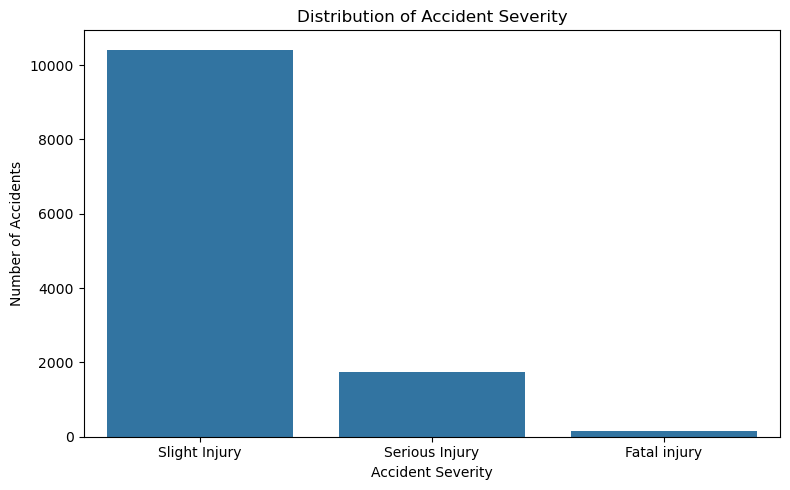

In [16]:
# Create a figure for the target distribution
plt.figure(figsize=(8, 5))
# Create a count plot for accident severity
sns.countplot(
    data=df,
    x=TARGET,
    order=df[TARGET].value_counts().index
)
# Add a title to the plot
plt.title("Distribution of Accident Severity")
# Label the x-axis
plt.xlabel("Accident Severity")
# Label the y-axis
plt.ylabel("Number of Accidents")
# Prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

### Observation

The target variable, Accident Severity, is highly imbalanced. The Slight Injury class contains the largest number of accidents, while the Fatal Injury class contains very few observations. The Serious Injury class has considerably fewer observations than the Slight Injury class.

This class imbalance should be considered during model training and evaluation because a model may achieve high overall accuracy by predicting the majority class more frequently. Therefore, weighted F1-score and confusion matrices will also be used along with accuracy to evaluate the classification models.

In [17]:
# Select all numerical columns from the dataset
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
# Display the numerical columns
print("Numerical Columns:")
print(numeric_columns)

Numerical Columns:
['Number_of_vehicles_involved', 'Number_of_casualties']


In [18]:
# Select all categorical/object columns from the dataset
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()
# Display the categorical columns
print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


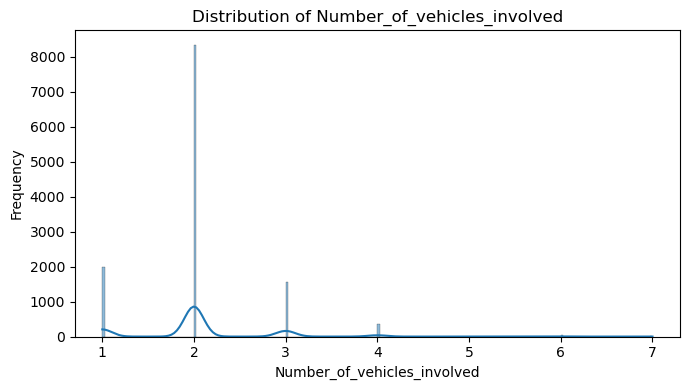

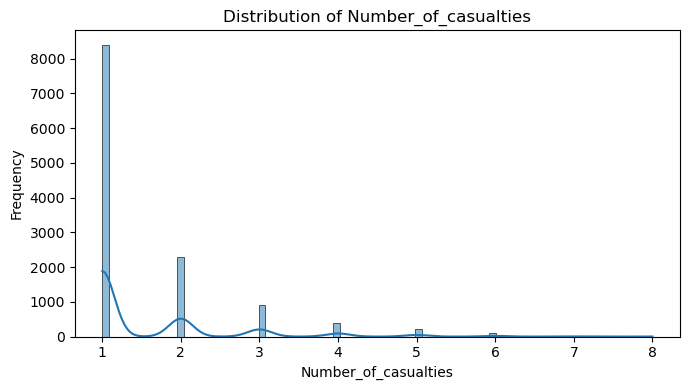

In [19]:
# Create distribution plots for every numerical feature
for column in numeric_columns:
    # Create a new figure for each feature
    plt.figure(figsize=(7, 4))
    # Plot the distribution of the selected feature
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    # Add the feature name as the plot title
    plt.title(f"Distribution of {column}")
    # Label the x-axis
    plt.xlabel(column)
    # Label the y-axis
    plt.ylabel("Frequency")
    # Adjust the layout
    plt.tight_layout()
    # Display the plot
    plt.show()

### Observation

The distribution of `Number_of_vehicles_involved` shows that most accidents involve 2 vehicles, followed by accidents involving 1 vehicle. Accidents involving 3 or more vehicles occur less frequently.

The distribution of `Number_of_casualties` shows that most accidents have 1 casualty, while the frequency decreases as the number of casualties increases. Both features are concentrated at lower values and show a right-skewed distribution.

These distributions indicate that the two numerical features have uneven frequencies across their possible values. This should be considered during preprocessing and model training.

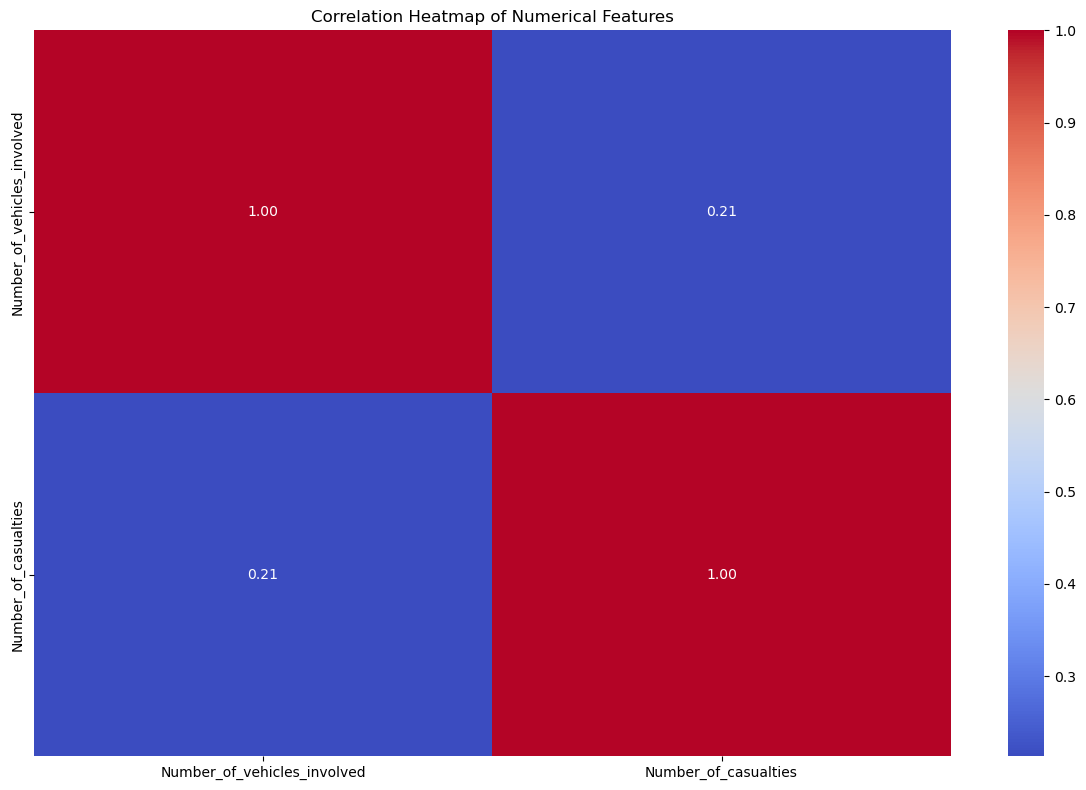

In [20]:
# Calculate correlations between numerical variables
correlation_matrix = df[numeric_columns].corr()
# Create the figure
plt.figure(figsize=(12, 8))
# Display the correlation matrix as a heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
# Add a title
plt.title("Correlation Heatmap of Numerical Features")
# Adjust the layout
plt.tight_layout()
# Display the heatmap
plt.show()

### Observation

The correlation heatmap shows that `Number_of_vehicles_involved` and `Number_of_casualties` have a correlation coefficient of 0.21.

This indicates a weak positive relationship between the two features. Therefore, an increase in the number of vehicles involved is associated with a slight tendency for the number of casualties to increase, but the relationship is not strong.

The diagonal values are 1.00 because each feature has a perfect correlation with itself.

In [21]:
# Create a copy of the dataset for visualization
eda_df = df.copy()
# Convert the target classes into numerical codes.
# This is ONLY for creating scatter plots and is not used
# as the target representation for model training.
eda_df["Severity_Code"] = pd.Categorical(
    eda_df[TARGET]
).codes
# Display the mapping between severity classes and codes
severity_mapping = dict(
    enumerate(pd.Categorical(df[TARGET]).categories)
)
print("Severity Mapping:")
print(severity_mapping)

Severity Mapping:
{0: 'Fatal injury', 1: 'Serious Injury', 2: 'Slight Injury'}


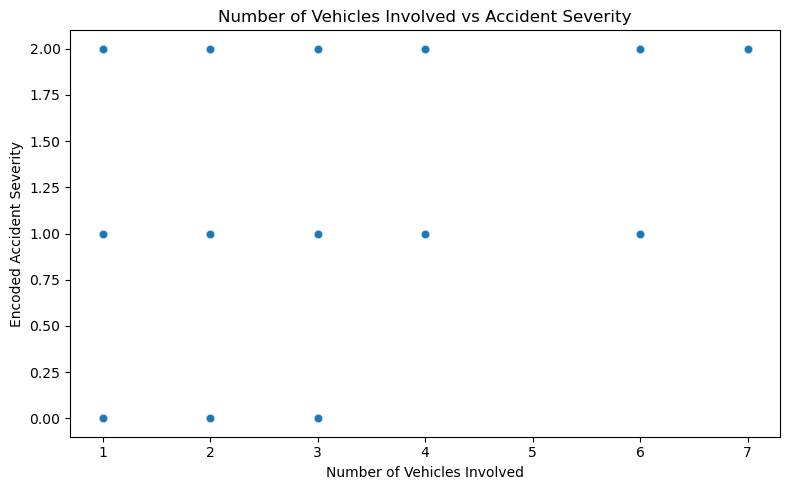

In [22]:
# Create a scatter plot between number of vehicles and accident severity
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=eda_df,
    x="Number_of_vehicles_involved",
    y="Severity_Code",
    alpha=0.5
)
# Add title
plt.title(
    "Number of Vehicles Involved vs Accident Severity"
)
# Label x-axis
plt.xlabel("Number of Vehicles Involved")
# Label y-axis
plt.ylabel("Encoded Accident Severity")
# Adjust layout
plt.tight_layout()
# Display the plot
plt.show()

### Observation

The scatter plot shows the relationship between `Number_of_vehicles_involved` and accident severity.

The three encoded accident severity classes can be observed across different numbers of vehicles involved. There is no clear separation between the severity classes based only on this feature.

Therefore, `Number_of_vehicles_involved` alone may not be sufficient to accurately distinguish between the different accident severity classes. Other features should also be considered by the classification models.

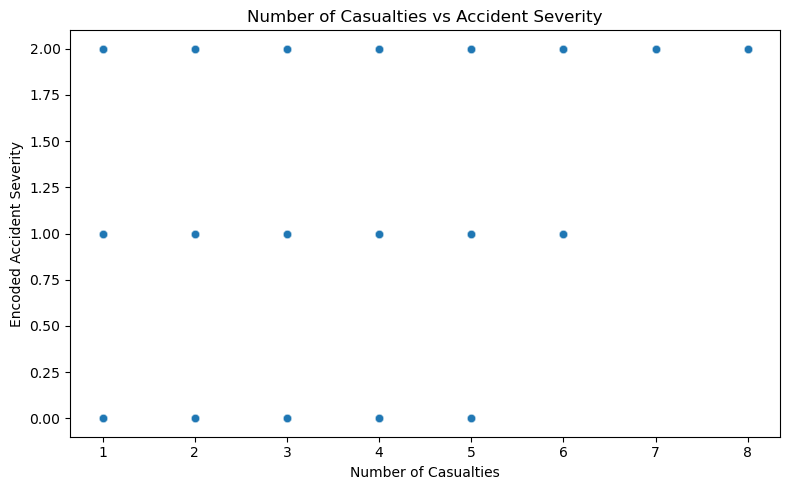

In [24]:
# Create a scatter plot showing the relationship between
# number of casualties and accident severity
plt.figure(figsize=(8, 5))
# Plot the number of casualties against the encoded severity
sns.scatterplot(
    data=eda_df,
    x="Number_of_casualties",
    y="Severity_Code",
    alpha=0.5
)
# Add a title to the plot
plt.title("Number of Casualties vs Accident Severity")
# Label the x-axis
plt.xlabel("Number of Casualties")
# Label the y-axis
plt.ylabel("Encoded Accident Severity")
# Adjust the spacing of the plot
plt.tight_layout()
# Display the plot
plt.show()

### Observation

The scatter plot shows the relationship between `Number_of_casualties` and `Accident_severity`.

The three accident severity classes occur across different numbers of casualties. Lower numbers of casualties are more frequently observed, while higher numbers occur less frequently. There is no clear separation between the three severity classes using the number of casualties alone.

Therefore, `Number_of_casualties` by itself may not be sufficient to predict accident severity, and multiple features should be considered during classification.

In [25]:
# Create a copy of the original dataset for machine learning
data = df.copy()
# Display the original dataset shape
print("Original dataset shape:", data.shape)

Original dataset shape: (12316, 32)


In [26]:
# Replace the string "na" with actual missing values
# so that the missing-value handling techniques can process them
data = data.replace("na", np.nan)
# Count missing values in every column
missing_values = data.isnull().sum()
# Display only columns that contain missing values
missing_values[missing_values > 0].sort_values(ascending=False)

Casualty_class             4443
Casualty_severity          4443
Age_band_of_casualty       4443
Sex_of_casualty            4443
Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64

In [27]:
# Count the number of rows before duplicate removal
rows_before = len(data)
# Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)
# Count the number of rows after duplicate removal
rows_after = len(data)
# Calculate the number of duplicates removed
duplicates_removed = rows_before - rows_after
# Display the result
print("Duplicate rows removed:", duplicates_removed)
print("Dataset shape after duplicate removal:", data.shape)

Duplicate rows removed: 0
Dataset shape after duplicate removal: (12316, 32)


In [28]:
# Calculate the number of missing values in every column
missing_count = data.isnull().sum()
# Calculate the percentage of missing values
missing_percentage = (
    missing_count / len(data)
) * 100
# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})
# Sort the table by missing percentage
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)
# Display the missing-value summary
missing_summary

,Missing Values,Missing Percentage
Sex_of_casualty,4443,36.075024
Age_band_of_casualty,4443,36.075024
Casualty_class,4443,36.075024
Casualty_severity,4443,36.075024
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014


### Missing-Value Treatment

Missing values were identified after converting the dataset's `"na"` entries into standard missing values.

Numerical missing values will be handled using the median, while categorical missing values will be handled using the most frequent category. These strategies will be implemented inside the preprocessing pipeline.

In [29]:
# Select numerical columns from the dataset
numeric_columns = data.select_dtypes(
    include=np.number
).columns.tolist()
# Display numerical columns
print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['Number_of_vehicles_involved', 'Number_of_casualties']


In [30]:
# Create an empty dictionary to store the number of outliers
outlier_counts = {}
# Check each numerical feature
for column in numeric_columns:
    # Calculate the first quartile
    Q1 = data[column].quantile(0.25)
    # Calculate the third quartile
    Q3 = data[column].quantile(0.75)
    # Calculate the interquartile range
    IQR = Q3 - Q1
    # Calculate the lower boundary
    lower_bound = Q1 - 1.5 * IQR
    # Calculate the upper boundary
    upper_bound = Q3 + 1.5 * IQR
    # Identify values outside the boundaries
    outliers = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )
    # Count the outliers
    outlier_counts[column] = outliers.sum()
# Convert the results into a DataFrame
outlier_summary = pd.DataFrame(
    outlier_counts.items(),
    columns=["Feature", "Outlier Count"]
)
# Display the outlier summary
outlier_summary

,Feature,Outlier Count
0,Number_of_vehicles_involved,3976
1,Number_of_casualties,720


### Outlier Observation

The numerical features were checked using the Interquartile Range (IQR) method.

Since `Number_of_vehicles_involved` and `Number_of_casualties` represent real accident characteristics, extreme values may represent genuine accidents rather than data-entry errors. Therefore, genuine extreme observations should not automatically be deleted.

In [31]:
# Convert the Time column into a datetime object
# Invalid values are converted to missing values
data["Time_parsed"] = pd.to_datetime(
    data["Time"],
    format="%H:%M:%S",
    errors="coerce"
)
# Extract the hour from the time
data["Hour"] = data["Time_parsed"].dt.hour
# Create a function to classify the time into traffic periods
def get_traffic_period(hour):
   # Morning period
    if 5 <= hour < 12:
        return "Morning"
    # Afternoon period
    elif 12 <= hour < 17:
        return "Afternoon"
    # Evening period
    elif 17 <= hour < 21:
        return "Evening"
    # Night period
    else:
        return "Night"

# Apply the function to create the new feature
data["Traffic_Period"] = data["Hour"].apply(
    get_traffic_period
)
# Display the new features
data[
    ["Time", "Hour", "Traffic_Period"]
].head()

,Time,Hour,Traffic_Period
0,17:02:00,17,Evening
1,17:02:00,17,Evening
2,17:02:00,17,Evening
3,1:06:00,1,Night
4,1:06:00,1,Night


### Feature Engineering Justification

The original `Time` feature was transformed into an `Hour` feature to represent the time of day numerically.

A second feature, `Traffic_Period`, was created by grouping the hour into Morning, Afternoon, Evening, and Night. Traffic conditions can vary according to the time of day, so these engineered features may provide useful information for predicting accident severity.

Accidents by Traffic Period:
Traffic_Period
Afternoon    3897
Evening      3496
Morning      3312
Night        1611
Name: count, dtype: int64

Most frequent traffic period:
Afternoon (3897 accidents)

Least frequent traffic period:
Night (1611 accidents)


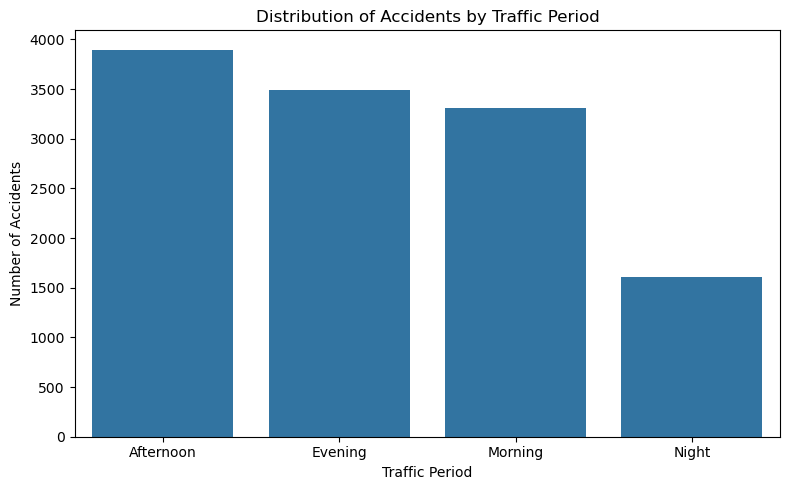

In [62]:
# Display the number of accidents occurring in each traffic period
traffic_period_counts = data["Traffic_Period"].value_counts()

# Print the distribution of accidents by traffic period
print("Accidents by Traffic Period:")
print(traffic_period_counts)

# Identify the traffic period with the highest number of accidents
most_frequent_period = traffic_period_counts.idxmax()

# Identify the traffic period with the lowest number of accidents
least_frequent_period = traffic_period_counts.idxmin()

# Get the corresponding accident counts
most_frequent_count = traffic_period_counts.max()
least_frequent_count = traffic_period_counts.min()

# Display the most and least frequent periods
print("\nMost frequent traffic period:")
print(
    f"{most_frequent_period} "
    f"({most_frequent_count} accidents)"
)

print("\nLeast frequent traffic period:")
print(
    f"{least_frequent_period} "
    f"({least_frequent_count} accidents)"
)

# Create a bar chart showing the distribution
plt.figure(figsize=(8, 5))

# Plot the traffic-period counts
sns.barplot(
    x=traffic_period_counts.index,
    y=traffic_period_counts.values
)

# Add the chart title
plt.title("Distribution of Accidents by Traffic Period")

# Label the x-axis
plt.xlabel("Traffic Period")

# Label the y-axis
plt.ylabel("Number of Accidents")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

### Observation

The traffic-period analysis shows that **Afternoon** has the highest number of recorded accidents, with **3,897 accidents**.

The **Night** period has the lowest number of recorded accidents, with **1,611 accidents**.

This indicates that accident occurrence varies across different times of the day. The traffic period feature may therefore provide useful information for accident-severity classification.

In [33]:
# Create a list of columns that should not be used as predictors
columns_to_drop = [
    "Accident_severity",
    "Casualty_severity",
    "Time"
]
# Remove the selected columns
# errors="ignore" prevents an error if a column is unavailable
data = data.drop(
    columns=columns_to_drop,
    errors="ignore"
)
# Display the remaining columns
print("Number of features:", data.shape[1])
# Display feature names
print(data.columns.tolist())

Number of features: 32
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Time_parsed', 'Hour', 'Traffic_Period']


In [34]:
# Define the target variable
TARGET = "Accident_severity"
# Reload the target from the original cleaned dataset
# because it was removed from the feature DataFrame above
y = df[TARGET].copy()
# Convert "na" to missing values in the target
y = y.replace("na", np.nan)
# Remove target rows that are missing, if any
valid_target_rows = y.notna()
# Keep only corresponding rows in X
X = data.loc[valid_target_rows].copy()
# Keep only valid target values
y = y.loc[valid_target_rows].copy()
# Reset indexes
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
# Display the shapes
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
# Display target classes
print("\nTarget classes:")
print(y.unique())

Feature matrix shape: (12316, 32)
Target shape: (12316,)

Target classes:
['Slight Injury' 'Serious Injury' 'Fatal injury']


In [35]:
# Start again from the cleaned dataset so that
# features and target always have matching rows
model_data = df.copy()
# Convert "na" values into missing values
model_data = model_data.replace("na", np.nan)
# Remove duplicate rows
model_data = model_data.drop_duplicates().reset_index(drop=True)
# Create the target variable
y = model_data[TARGET].copy()
# Create the feature matrix
X = model_data.drop(
    columns=[
        TARGET,
        "Casualty_severity",
        "Time"
    ],
    errors="ignore"
)
# Create the engineered Hour feature from Time
time_values = pd.to_datetime(
    model_data["Time"],
    format="%H:%M:%S",
    errors="coerce"
)
# Add hour as a numerical feature
X["Hour"] = time_values.dt.hour
# Create traffic period
X["Traffic_Period"] = X["Hour"].apply(
    get_traffic_period
)
# Display shapes
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
# Display target distribution
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (12316, 31)
Target shape: (12316,)

Target distribution:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


In [36]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
# test_size=0.20 means 20% of the data is used for testing
# stratify=y maintains approximately the same class distribution
# in both training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
# Display the resulting shapes
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (9852, 31)
Testing feature shape: (2464, 31)

Training target distribution:
Accident_severity
Slight Injury     8331
Serious Injury    1394
Fatal injury       127
Name: count, dtype: int64

Testing target distribution:
Accident_severity
Slight Injury     2084
Serious Injury     349
Fatal injury        31
Name: count, dtype: int64


In [37]:
# Identify numerical features from the training data
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

# Identify categorical features from the training data
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Display numerical features
print("Numerical features:")
print(numeric_features)

# Display categorical features
print("\nCategorical features:")
print(categorical_features)

# Display the total number of each type
print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour']

Categorical features:
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Traffic_Period']

Number of numerical features: 3
Number of categorical features: 28


In [38]:
# Import Pipeline for creating a sequence of preprocessing steps
from sklearn.pipeline import Pipeline

# Import ColumnTransformer for applying different preprocessing
# to numerical and categorical columns
from sklearn.compose import ColumnTransformer

# Import SimpleImputer for handling missing values
from sklearn.impute import SimpleImputer

# Import StandardScaler for numerical feature scaling
from sklearn.preprocessing import StandardScaler

# Import OneHotEncoder for categorical feature encoding
from sklearn.preprocessing import OneHotEncoder

# Display confirmation
print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [39]:
# Create a preprocessing pipeline for numerical features
numeric_pipeline = Pipeline(
    steps=[

        # Replace missing numerical values with the median
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        # Standardize numerical features
        # so that they have approximately mean 0 and standard deviation 1
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Display confirmation
print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [40]:
# Create a preprocessing pipeline for categorical features
categorical_pipeline = Pipeline(
    steps=[

        # Replace missing categorical values with
        # the most frequently occurring category
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        # Convert categorical values into numerical binary columns
        # handle_unknown="ignore" prevents errors when the test set
        # contains a category not seen during training
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Display confirmation
print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [41]:
# Combine the numerical and categorical pipelines
# using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[

        # Apply numerical pipeline to numerical columns
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),

        # Apply categorical pipeline to categorical columns
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# Display confirmation
print("Complete preprocessing pipeline created successfully.")

Complete preprocessing pipeline created successfully.


In [42]:
# Fit the preprocessing pipeline ONLY on the training data
# This prevents information from the test set leaking into training
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Display the processed dimensions
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (9852, 203)
Processed testing shape: (2464, 203)


In [43]:
# Check whether missing values remain in the processed training data
training_missing = np.isnan(X_train_processed).sum()

# Check whether missing values remain in the processed testing data
testing_missing = np.isnan(X_test_processed).sum()

# Display the results
print("Missing values in processed training data:", training_missing)
print("Missing values in processed testing data:", testing_missing)

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [44]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Import Support Vector Machine classifier
from sklearn.svm import SVC

# Display confirmation
print("Five Classification Part-A algorithms imported successfully.")

Five Classification Part-A algorithms imported successfully.


1. Logistic Regression
2. KNN
3. Gaussian Naive Bayes
4. Decision Tree
5. SVM

In [45]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression classifier
# class_weight="balanced" gives additional importance to minority classes
# max_iter=1000 allows sufficient iterations for model convergence
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the Logistic Regression model using training data
logistic_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the unseen test data
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

# Display confirmation
print("Logistic Regression trained successfully.")
print("Predictions generated successfully.")

Logistic Regression trained successfully.
Predictions generated successfully.


### Logistic Regression

Logistic Regression is used as the baseline classification algorithm. It estimates the probability of an observation belonging to each accident severity class.

The model provides interpretable coefficients that can be used to understand the effect of features on the predicted class.

In [46]:
# Import K-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN classifier
# n_neighbors=5 means the five nearest training observations
# are considered when making a prediction
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

# Train the KNN model
knn_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
y_pred_knn = knn_model.predict(
    X_test_processed
)

# Display confirmation
print("KNN trained successfully.")
print("Predictions generated successfully.")

KNN trained successfully.
Predictions generated successfully.


### K-Nearest Neighbors

KNN classifies an observation based on the classes of its nearest neighboring observations.

The value of k controls the number of neighbors considered. A small k can make the model sensitive to individual observations, while a larger k produces smoother decision boundaries.

Euclidean distance is used as the distance metric in the baseline model.

In [47]:

# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Create the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model using the processed training data
gnb_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
y_pred_gnb = gnb_model.predict(
    X_test_processed
)

# Display confirmation
print("Gaussian Naive Bayes trained successfully.")
print("Predictions generated successfully.")

Gaussian Naive Bayes trained successfully.
Predictions generated successfully.


### Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm.

It assumes that the features are conditionally independent given the target class. Although this assumption may not always hold in real-world accident data, the algorithm provides a useful baseline for comparison with the other classifiers.

In [48]:
# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree classifier
# class_weight="balanced" helps compensate for class imbalance
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train the Decision Tree
decision_tree_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
y_pred_tree = decision_tree_model.predict(
    X_test_processed
)

# Display confirmation
print("Decision Tree trained successfully.")
print("Predictions generated successfully.")

Decision Tree trained successfully.
Predictions generated successfully.


### Decision Tree

A Decision Tree classifies observations by creating a sequence of decision rules based on feature values.

Decision Trees are easy to interpret and can be visualized. The `max_depth` parameter can be tuned later to control the complexity of the tree and reduce overfitting.

In [49]:
# Import Support Vector Classifier
from sklearn.svm import SVC

# Create the SVM classifier
# class_weight="balanced" gives more importance to minority classes
# probability=True enables probability estimation
svm_model = SVC(
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)

# Train the SVM model
svm_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
y_pred_svm = svm_model.predict(
    X_test_processed
)

# Display confirmation
print("SVM trained successfully.")
print("Predictions generated successfully.")

SVM trained successfully.
Predictions generated successfully.


### Support Vector Machine

Support Vector Machine finds a decision boundary that separates different classes.

Feature scaling is important for SVM because its distance and optimization calculations are affected by the scale of the input features. The numerical features were therefore standardized during preprocessing.

The `C` parameter and kernel can be considered for future tuning.

In [50]:
# Store all model predictions in a dictionary
# This makes it easier to evaluate every algorithm consistently

model_predictions = {
    "Logistic Regression": y_pred_logistic,
    "K-Nearest Neighbors": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_gnb,
    "Decision Tree": y_pred_tree,
    "Support Vector Machine": y_pred_svm
}

# Display the models included in the comparison
print("Models evaluated:")
for model_name in model_predictions:
    print("-", model_name)

Models evaluated:
- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Decision Tree
- Support Vector Machine


In [51]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, f1_score

# Create an empty list to store evaluation results
evaluation_results = []

# Evaluate every classification model
for model_name, predictions in model_predictions.items():

    # Calculate accuracy
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    # Calculate weighted F1-score
    # Weighted averaging considers the number of samples
    # belonging to each class
    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    # Store the results
    evaluation_results.append({
        "Algorithm": model_name,
        "Accuracy": accuracy,
        "Weighted F1-Score": weighted_f1
    })

# Convert results into a DataFrame
comparison_df = pd.DataFrame(
    evaluation_results
)

# Sort models by weighted F1-score
comparison_df = comparison_df.sort_values(
    by="Weighted F1-Score",
    ascending=False
).reset_index(drop=True)

# Display the comparison table
comparison_df

,Algorithm,Accuracy,Weighted F1-Score
0,K-Nearest Neighbors,0.838474,0.789280
1,Decision Tree,0.759334,0.763312
2,Support Vector Machine,0.692370,0.726671
3,Logistic Regression,0.506899,0.590494
4,Gaussian Naive Bayes,0.091315,0.124066


In [52]:
# Create a copy of the comparison table for presentation
comparison_display = comparison_df.copy()

# Round Accuracy to four decimal places
comparison_display["Accuracy"] = (
    comparison_display["Accuracy"].round(4)
)

# Round Weighted F1-score to four decimal places
comparison_display["Weighted F1-Score"] = (
    comparison_display["Weighted F1-Score"].round(4)
)

# Display the final preliminary comparison table
comparison_display

,Algorithm,Accuracy,Weighted F1-Score
0,K-Nearest Neighbors,0.8385,0.7893
1,Decision Tree,0.7593,0.7633
2,Support Vector Machine,0.6924,0.7267
3,Logistic Regression,0.5069,0.5905
4,Gaussian Naive Bayes,0.0913,0.1241


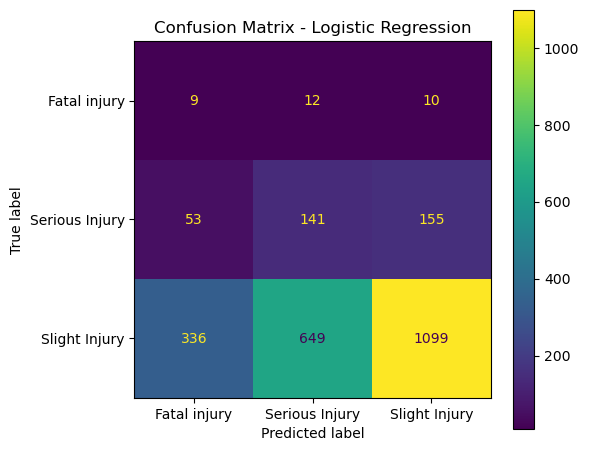

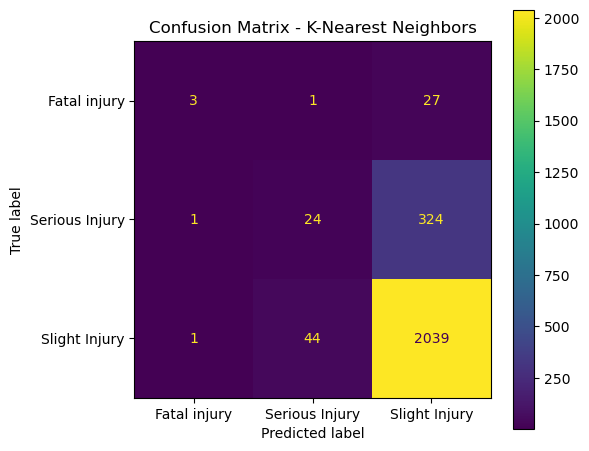

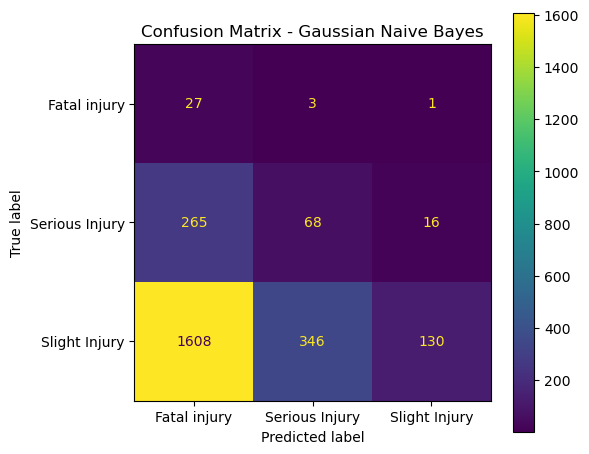

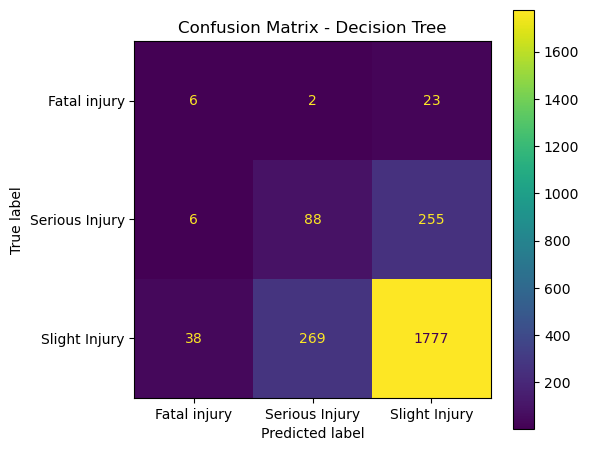

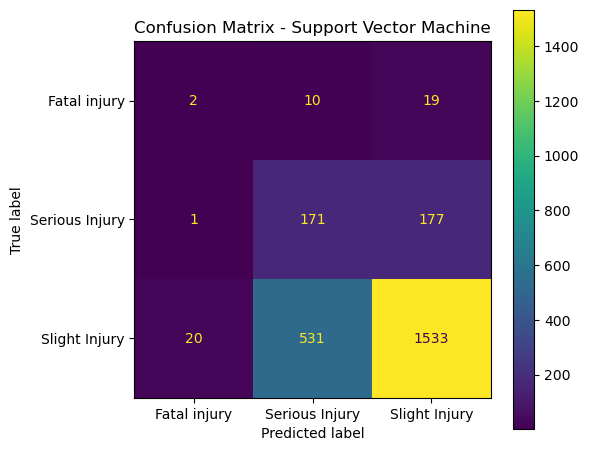

In [53]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the unique target classes
class_labels = sorted(y_test.unique())

# Generate a confusion matrix for every algorithm
for model_name, predictions in model_predictions.items():

    # Calculate the confusion matrix
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=class_labels
    )

    # Create the confusion matrix display
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )

    # Create a separate figure for each model
    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    # Display the confusion matrix
    cm_display.plot(
        ax=ax,
        values_format="d"
    )

    # Add the model name
    ax.set_title(
        f"Confusion Matrix - {model_name}"
    )

    # Adjust layout
    plt.tight_layout()

    # Display the figure
    plt.show()

In [61]:
# Import classification report
from sklearn.metrics import classification_report

# Generate a detailed classification report for every model
for model_name, predictions in model_predictions.items():

    # Print a separator
    print("=" * 75)

    # Print the model name
    print(model_name)

    # Print another separator
    print("=" * 75)

    # Generate and display the classification report
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
                precision    recall  f1-score   support

  Fatal injury       0.02      0.29      0.04        31
Serious Injury       0.18      0.40      0.25       349
 Slight Injury       0.87      0.53      0.66      2084

      accuracy                           0.51      2464
     macro avg       0.36      0.41      0.31      2464
  weighted avg       0.76      0.51      0.59      2464

K-Nearest Neighbors
                precision    recall  f1-score   support

  Fatal injury       0.60      0.10      0.17        31
Serious Injury       0.35      0.07      0.11       349
 Slight Injury       0.85      0.98      0.91      2084

      accuracy                           0.84      2464
     macro avg       0.60      0.38      0.40      2464
  weighted avg       0.78      0.84      0.79      2464

Gaussian Naive Bayes
                precision    recall  f1-score   support

  Fatal injury       0.01      0.87      0.03        31
Serious Injury       0.16      0.19 

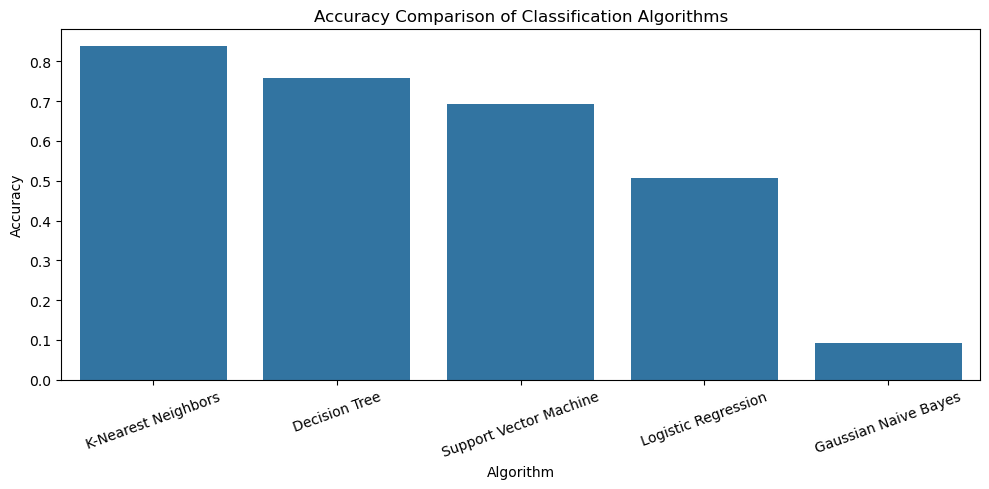

In [55]:
# Create a figure for the accuracy comparison
plt.figure(figsize=(10, 5))

# Create a bar chart using the comparison table
sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="Accuracy"
)

# Add the title
plt.title(
    "Accuracy Comparison of Classification Algorithms"
)

# Label the x-axis
plt.xlabel("Algorithm")

# Label the y-axis
plt.ylabel("Accuracy")

# Rotate algorithm names for readability
plt.xticks(rotation=20)

# Adjust layout
plt.tight_layout()

# Display the graph
plt.show()

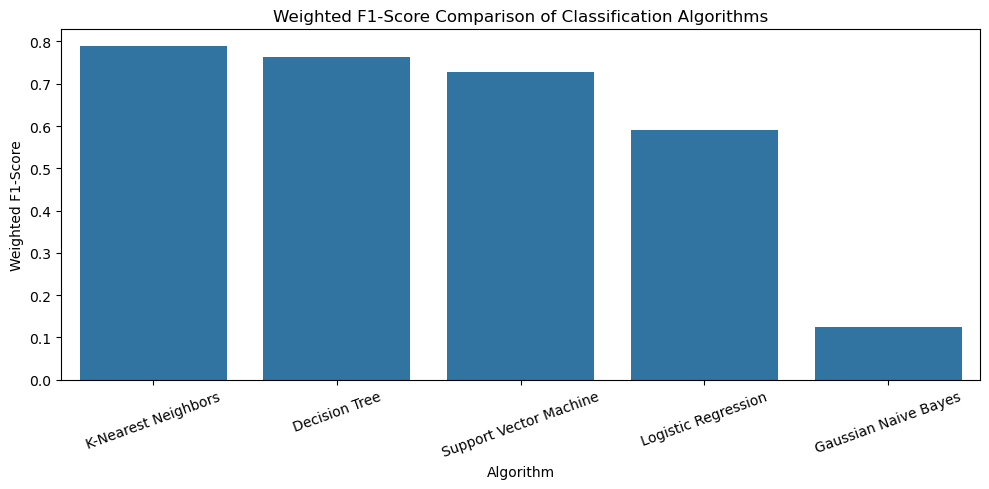

In [56]:
# Create a figure for weighted F1-score comparison
plt.figure(figsize=(10, 5))

# Create a bar chart
sns.barplot(
    data=comparison_df,
    x="Algorithm",
    y="Weighted F1-Score"
)

# Add the title
plt.title(
    "Weighted F1-Score Comparison of Classification Algorithms"
)

# Label the x-axis
plt.xlabel("Algorithm")

# Label the y-axis
plt.ylabel("Weighted F1-Score")

# Rotate algorithm names
plt.xticks(rotation=20)

# Adjust layout
plt.tight_layout()

# Display the graph
plt.show()

In [57]:
# Find the model with the highest weighted F1-score
best_model_row = comparison_df.iloc[0]

# Extract the best model name
best_model_name = best_model_row["Algorithm"]

# Extract its accuracy
best_accuracy = best_model_row["Accuracy"]

# Extract its weighted F1-score
best_f1 = best_model_row["Weighted F1-Score"]

# Display the preliminary best model
print("Preliminary Best Model")
print("----------------------")
print("Algorithm:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))
print("Weighted F1-Score:", round(best_f1, 4))

Preliminary Best Model
----------------------
Algorithm: K-Nearest Neighbors
Accuracy: 0.8385
Weighted F1-Score: 0.7893


### Preliminary Comparison

The five Part-A classification algorithms were trained and evaluated on the same stratified test set.

Accuracy and weighted F1-score were used for comparison. Since the accident severity target is imbalanced, weighted F1-score is considered alongside accuracy rather than relying on accuracy alone.

The model with the highest weighted F1-score is considered the preliminary best-performing model before any further model-specific analysis.

In [63]:
# Get the feature names generated by the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Get the coefficient matrix from Logistic Regression
# Since this is a multiclass classification problem,
# there is one coefficient row for each target class
coefficients = logistic_model.coef_

# Get the class names used by Logistic Regression
class_names = logistic_model.classes_

# Create a DataFrame containing coefficients for every class
logistic_coefficients = pd.DataFrame(
    coefficients.T,
    index=feature_names,
    columns=class_names
)

# Add the feature names as a normal column
logistic_coefficients = logistic_coefficients.reset_index()

# Rename the first column to "Feature"
logistic_coefficients = logistic_coefficients.rename(
    columns={"index": "Feature"}
)

# Display the complete coefficient table
print("Logistic Regression Coefficients:")
display(logistic_coefficients)

# --------------------------------------------------
# Find the most influential features for each class
# --------------------------------------------------

# Loop through every target class
for class_name in class_names:

    # Sort features according to the absolute coefficient value
    # so that the strongest features appear first
    top_features = (
        logistic_coefficients[
            ["Feature", class_name]
        ]
        .assign(
            Absolute_Coefficient=lambda x:
            x[class_name].abs()
        )
        .sort_values(
            by="Absolute_Coefficient",
            ascending=False
        )
        .head(10)
    )

    # Display the top 10 features
    print("\n" + "=" * 60)
    print(
        f"Top 10 Features for Class: {class_name}"
    )
    print("=" * 60)

    display(top_features)

Logistic Regression Coefficients:


,Feature,Fatal injury,Serious Injury,Slight Injury
0,numerical__Number_of_vehicles_involved,-0.415714,0.051610,0.364105
1,numerical__Number_of_casualties,0.491567,-0.195087,-0.296480
2,numerical__Hour,0.154913,-0.063420,-0.091493
3,categorical__Day_of_week_Friday,-0.267141,0.191792,0.075349
4,categorical__Day_of_week_Monday,-0.150823,-0.023395,0.174218
...,...,...,...,...
198,categorical__Cause_of_accident_Unknown,-0.884310,-0.049708,0.934018
199,categorical__Traffic_Period_Afternoon,-0.219050,0.079259,0.139791
200,categorical__Traffic_Period_Evening,-0.179793,0.072172,0.107621
201,categorical__Traffic_Period_Morning,-0.140675,0.032887,0.107788



Top 10 Features for Class: Fatal injury


,Feature,Fatal injury,Absolute_Coefficient
169,categorical__Fitness_of_casuality_Other,2.353623,2.353623
106,categorical__Road_surface_type_Gravel roads,-2.321344,2.321344
71,categorical__Area_accident_occured_ Outside ru...,-2.165934,2.165934
23,categorical__Educational_level_Unknown,-2.156537,2.156537
78,categorical__Area_accident_occured_Unknown,2.035790,2.035790
90,categorical__Road_allignment_Steep grade upwar...,1.915554,1.915554
120,categorical__Weather_conditions_Raining,1.910752,1.910752
69,categorical__Area_accident_occured_ Hospital a...,-1.883007,1.883007
118,categorical__Weather_conditions_Normal,1.766274,1.766274
185,categorical__Cause_of_accident_Drunk driving,-1.765543,1.765543



Top 10 Features for Class: Serious Injury


,Feature,Serious Injury,Absolute_Coefficient
106,categorical__Road_surface_type_Gravel roads,1.313455,1.313455
23,categorical__Educational_level_Unknown,1.233295,1.233295
71,categorical__Area_accident_occured_ Outside ru...,1.205356,1.205356
140,categorical__Vehicle_movement_Overtaking,-1.156121,1.156121
78,categorical__Area_accident_occured_Unknown,-0.990533,0.990533
120,categorical__Weather_conditions_Raining,-0.917016,0.917016
49,categorical__Type_of_vehicle_Special vehicle,0.916129,0.916129
147,categorical__Vehicle_movement_Waiting to go,-0.900720,0.900720
145,categorical__Vehicle_movement_U-Turn,0.891134,0.891134
123,categorical__Weather_conditions_Unknown,0.864466,0.864466



Top 10 Features for Class: Slight Injury


,Feature,Slight Injury,Absolute_Coefficient
169,categorical__Fitness_of_casuality_Other,-1.611851,1.611851
90,categorical__Road_allignment_Steep grade upwar...,-1.432578,1.432578
118,categorical__Weather_conditions_Normal,-1.169150,1.169150
69,categorical__Area_accident_occured_ Hospital a...,1.148674,1.148674
165,categorical__Fitness_of_casuality_Blind,1.107141,1.107141
78,categorical__Area_accident_occured_Unknown,-1.045257,1.045257
106,categorical__Road_surface_type_Gravel roads,1.007889,1.007889
120,categorical__Weather_conditions_Raining,-0.993736,0.993736
185,categorical__Cause_of_accident_Drunk driving,0.993172,0.993172
34,categorical__Driving_experience_No Licence,0.970645,0.970645


### Logistic Regression Coefficient Interpretation

Logistic Regression provides coefficients that help interpret the relationship between the input features and the predicted accident-severity classes.

Because this is a multiclass classification problem, a separate set of coefficients is obtained for each accident-severity class.

A positive coefficient indicates a positive contribution toward the corresponding class, while a negative coefficient indicates a negative contribution. Larger absolute coefficient values indicate stronger model influence relative to other features.

The coefficients are interpreted as model associations rather than direct causal relationships.

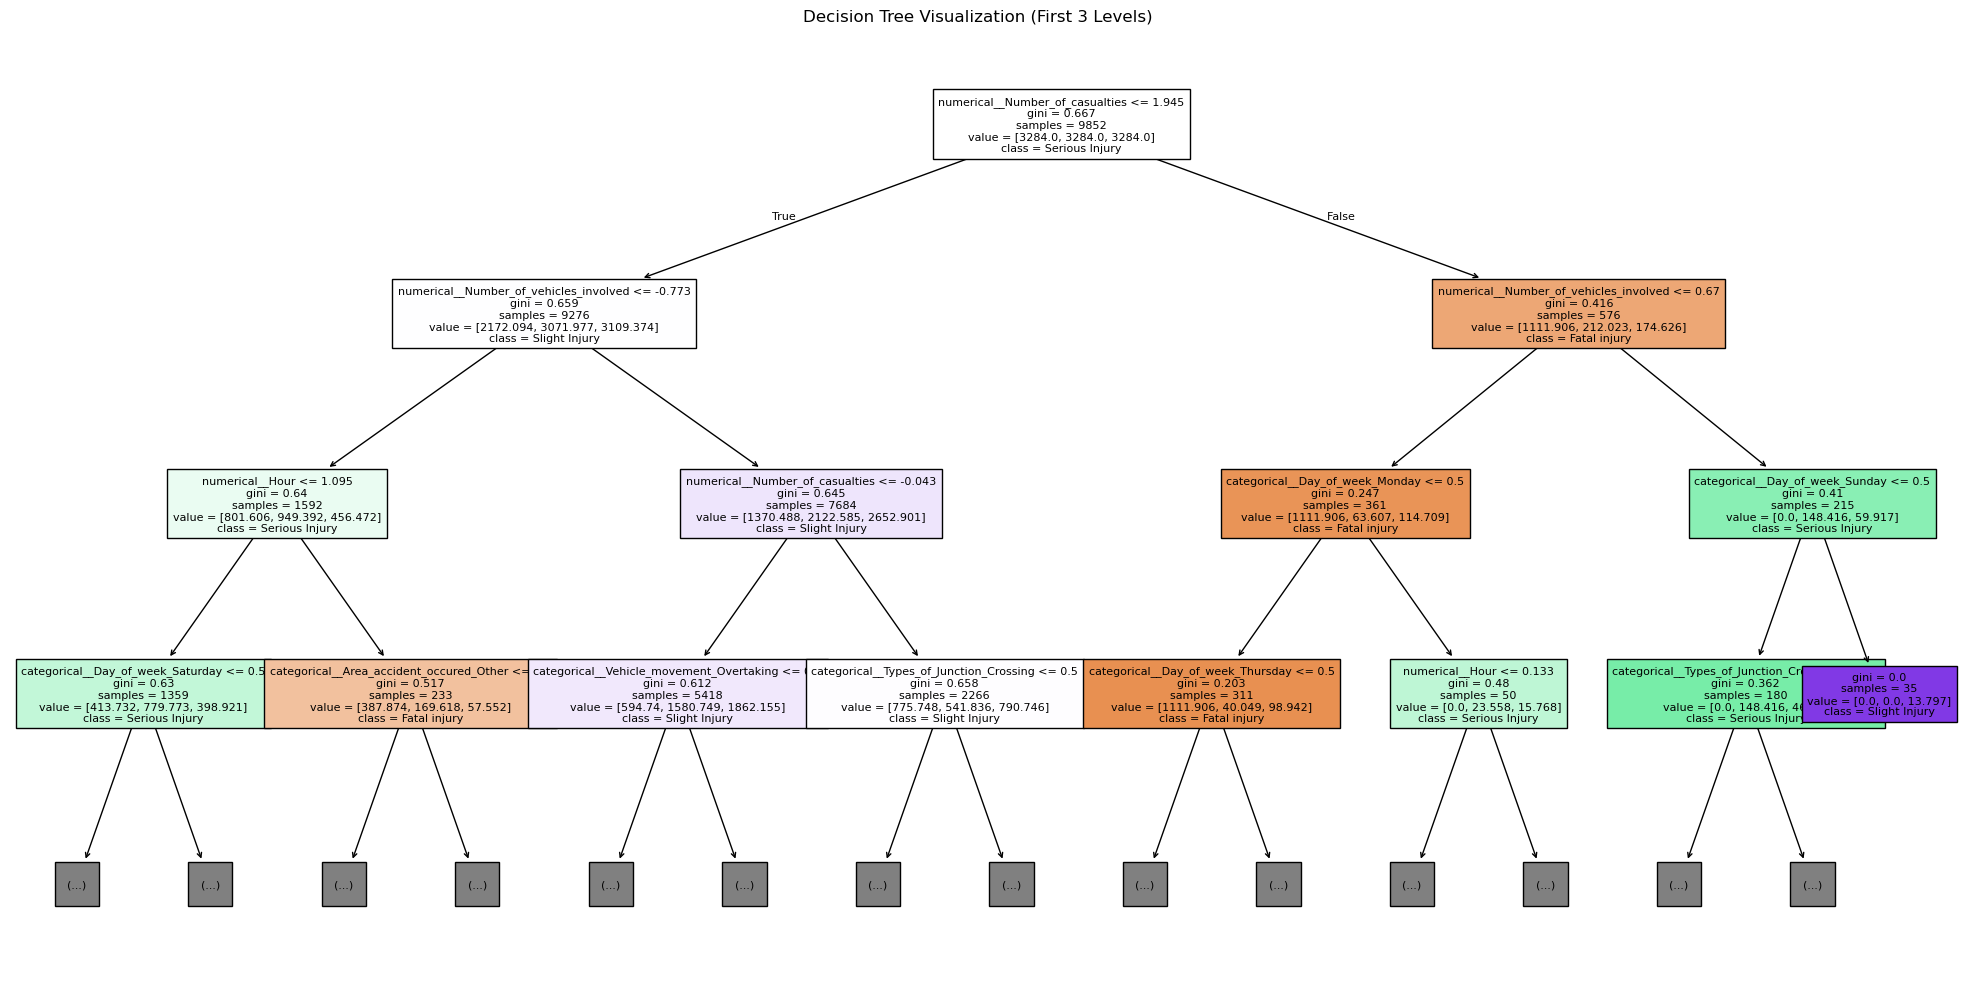

In [59]:
# Import the tree plotting function
from sklearn.tree import plot_tree

# Create a large figure for the Decision Tree
plt.figure(figsize=(20, 10))

# Visualize the first few levels of the tree
# max_depth controls only the displayed depth here,
# not the trained model itself
plot_tree(
    decision_tree_model,
    max_depth=3,
    filled=True,
    feature_names=feature_names,
    class_names=[
        str(label) for label in sorted(y_train.unique())
    ],
    fontsize=8
)

# Add a title
plt.title(
    "Decision Tree Visualization (First 3 Levels)"
)

# Adjust layout
plt.tight_layout()

# Display the tree
plt.show()

## Algorithm Discussion

### 1. Logistic Regression
Logistic Regression is used as the baseline classifier. Its coefficients provide an interpretable indication of how features influence the predicted classes.

### 2. K-Nearest Neighbors
KNN classifies observations based on nearby training observations. The value of `k` affects model behavior. A small `k` can be sensitive to noise, while a larger `k` provides smoother predictions. The baseline model uses Euclidean distance.

### 3. Gaussian Naive Bayes
Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes conditional independence between features given the target class. This assumption may not always hold for accident-related variables, but the algorithm provides a useful comparison.

### 4. Decision Tree
Decision Tree creates a sequence of feature-based decision rules. It is interpretable and can be visualized. The `max_depth` parameter can be used to control tree complexity and reduce overfitting.

### 5. Support Vector Machine
SVM attempts to find decision boundaries that separate the classes. Feature scaling is important for SVM, which is why numerical features were standardized during preprocessing. The `C` parameter and kernel determine the behavior of the classifier.

In [60]:
# Verify that all five models generated predictions
print("Classification Part-A Checklist")
print("---------------------------------")

for model_name, predictions in model_predictions.items():

    # Check that predictions were generated
    print(
        f"{model_name}: "
        f"{len(predictions)} predictions generated"
    )

# Confirm evaluation table
print("\nEvaluation table created:", not comparison_df.empty)

# Confirm required metrics exist
print(
    "Accuracy available:",
    "Accuracy" in comparison_df.columns
)

print(
    "Weighted F1 available:",
    "Weighted F1-Score" in comparison_df.columns
)

Classification Part-A Checklist
---------------------------------
Logistic Regression: 2464 predictions generated
K-Nearest Neighbors: 2464 predictions generated
Gaussian Naive Bayes: 2464 predictions generated
Decision Tree: 2464 predictions generated
Support Vector Machine: 2464 predictions generated

Evaluation table created: True
Accuracy available: True
Weighted F1 available: True


### Preliminary Model Comparison

Five Part-A classification algorithms were trained and evaluated using the same stratified test dataset.

K-Nearest Neighbors achieved the best preliminary performance with an accuracy of 83.85% and a weighted F1-score of 78.93%.

Decision Tree was the second-best model, achieving an accuracy of 75.93% and a weighted F1-score of 76.33%. Support Vector Machine achieved an accuracy of 69.24% and a weighted F1-score of 72.67%.

Logistic Regression achieved an accuracy of 50.69% and a weighted F1-score of 59.05%. Gaussian Naive Bayes showed the lowest performance, with an accuracy of 9.13% and a weighted F1-score of 12.41%.

Based on the preliminary comparison, K-Nearest Neighbors is the best-performing model among the five Part-A algorithms. However, the confusion matrices and class-wise performance should also be considered before drawing a final conclusion because the accident severity classes are imbalanced.